# Late Fusion: Audio-CNN + FastText

This notebook evaluates late fusion of a mel-spectrogram CNN (audio) with a FastText classifier (text/OCR) for 3-language identification (English, Malay, Chinese) on the noisy OCR dataset.

In [27]:
# Imports
import os
import json
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import fasttext
import fasttext.util

# Device
print("Hi")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Hi
Device: cuda
GPU: NVIDIA GeForce GTX 1650


In [28]:
# Configuration
AUDIO_DIR = os.path.join(os.getcwd(), 'Dataset', 'audio_active')
OCR_BASE_DIR = os.path.join(os.getcwd(), 'ocr_images_noisy')

USE_450MIN = True  # set True to use *_active_450min.wav if available
AUDIO_ACTIVE_NAME = '7.5h.wav' if USE_450MIN else 'active.wav'

SAMPLE_RATE = 16000
SEGMENT_LENGTH = 3  # seconds for CNN
N_MELS = 128
ACTIVE_DATA_RATIO = 1.0 if USE_450MIN else 0.6
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15
LANGUAGES = ['en', 'ms', 'zh']
LANGUAGE_IDS = {'en': 0, 'ms': 1, 'zh': 2}
LANGUAGE_NAMES = ['English', 'Malay', 'Chinese']

AUDIO_MODEL_PATH = 'best_cnn_fixed_model.pth'
FASTTEXT_MODEL_PATH = 'fasttext_best_model.bin'

print(f'Audio dir: {AUDIO_DIR}')
print(f'OCR dir:   {OCR_BASE_DIR}')
print(f'Using audio file suffix: {AUDIO_ACTIVE_NAME}, ACTIVE_DATA_RATIO={ACTIVE_DATA_RATIO}')

Audio dir: c:\Users\Aaron Lim\Dropbox\PC\Documents\1School\FYP\Dataset\audio_active
OCR dir:   c:\Users\Aaron Lim\Dropbox\PC\Documents\1School\FYP\ocr_images_noisy
Using audio file suffix: 7.5h.wav, ACTIVE_DATA_RATIO=1.0


In [29]:
# Load and segment audio (3s, temporal split)
audio_segments_full = {lc: [] for lc in LANGUAGES}

def load_segments(lang_code):
    audio_file = os.path.join(AUDIO_DIR, f'{lang_code}_{AUDIO_ACTIVE_NAME}')
    if not os.path.exists(audio_file):
        # fallback to legacy name
        fallback = os.path.join(AUDIO_DIR, f'{lang_code}_active.wav')
        if os.path.exists(fallback):
            audio_file = fallback
        else:
            print(f'Warning: missing audio file for {lang_code}')
            return []
    waveform, sr = librosa.load(audio_file, sr=SAMPLE_RATE)
    seg_len = SEGMENT_LENGTH * SAMPLE_RATE
    num_segments = len(waveform) // seg_len
    segments = []
    for i in range(num_segments):
        start = i * seg_len
        end = start + seg_len
        segments.append(waveform[start:end])
    return segments

for lc in LANGUAGES:
    audio_segments_full[lc] = load_segments(lc)
    print(f'{lc}: {len(audio_segments_full[lc])} segments')

# Take first active ratio (default 100% when using 450min)
audio_samples = []
audio_labels = []
for lc in LANGUAGES:
    segs = audio_segments_full[lc]
    active_count = int(len(segs) * ACTIVE_DATA_RATIO)
    active = segs[:active_count]
    audio_samples.extend(active)
    audio_labels.extend([LANGUAGE_IDS[lc]] * len(active))
    print(f'{lc}: active {len(active)}/{len(segs)}')

# Split active set into train/val/test (70/15/15)
train_audio = []
val_audio = []
test_audio = []
train_labels = []
val_labels = []
test_labels = []
test_audio_by_lang = {lc: [] for lc in LANGUAGES}

for lc in LANGUAGES:
    segs = audio_segments_full[lc][:int(len(audio_segments_full[lc]) * ACTIVE_DATA_RATIO)]
    total = len(segs)
    train_cut = int(total * TRAIN_RATIO)
    val_cut = train_cut + int(total * VAL_RATIO)
    train_audio.extend(segs[:train_cut])
    val_audio.extend(segs[train_cut:val_cut])
    test_slice = segs[val_cut:]
    test_audio.extend(test_slice)
    test_audio_by_lang[lc] = test_slice
    train_labels.extend([LANGUAGE_IDS[lc]] * len(segs[:train_cut]))
    val_labels.extend([LANGUAGE_IDS[lc]] * len(segs[train_cut:val_cut]))
    test_labels.extend([LANGUAGE_IDS[lc]] * len(test_slice))

print(f'Train/Val/Test sizes: {len(train_audio)}/{len(val_audio)}/{len(test_audio)}')

en: 9003 segments
ms: 9003 segments
zh: 9002 segments
en: active 9003/9003
ms: active 9003/9003
zh: active 9002/9002
Train/Val/Test sizes: 18905/4050/4053


In [30]:
# Audio CNN definition and loader
class MelSpectrogramCNN(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.AdaptiveMaxPool2d((4, 4))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(256 * 4 * 4, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

# Load checkpoint
audio_model = MelSpectrogramCNN(num_classes=len(LANGUAGE_NAMES))
if os.path.exists(AUDIO_MODEL_PATH):
    state = torch.load(AUDIO_MODEL_PATH, map_location=device)
    audio_model.load_state_dict(state)
    print(f'Loaded audio CNN from {AUDIO_MODEL_PATH}')
else:
    print('Warning: audio checkpoint not found; using randomly initialized CNN')

audio_model = audio_model.to(device)
audio_model.eval()

def to_mel(waveform):
    mel = librosa.feature.melspectrogram(y=waveform, sr=SAMPLE_RATE, n_mels=N_MELS)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    return mel_db

def get_audio_probs(waveforms, batch_size=64):
    probs = []
    use_amp = device.type == 'cuda'
    with torch.no_grad():
        for i in range(0, len(waveforms), batch_size):
            batch = waveforms[i:i+batch_size]
            mels = [to_mel(w) for w in batch]
            # Pad to max time dimension
            max_t = max(m.shape[1] for m in mels)
            mels_pad = []
            for m in mels:
                pad_width = max_t - m.shape[1]
                if pad_width > 0:
                    m = np.pad(m, ((0,0),(0,pad_width)), mode='constant')
                mels_pad.append(m)
            tensor = torch.from_numpy(np.array(mels_pad)).float().unsqueeze(1).to(device)
            if use_amp:
                with torch.cuda.amp.autocast():
                    logits = audio_model(tensor)
            else:
                logits = audio_model(tensor)
            probs.append(torch.softmax(logits, dim=-1).cpu().numpy())
    return np.vstack(probs)

In [31]:
# Load OCR text (noisy) with fallback to clean labels
import re
import csv

folder_map = {'en': 'EN', 'ms': 'MY', 'zh': 'CN'}

def clean_text(s):
    if not isinstance(s, str):
        s = str(s)
    s = re.sub(r'[\r\n\t]+', ' ', s)
    s = re.sub(r'\s+', ' ', s)
    return s.strip()

text_samples_full = {lc: [] for lc in LANGUAGES}
for lc in LANGUAGES:
    lang_dir = os.path.join(OCR_BASE_DIR, folder_map[lc])
    labels_file = os.path.join(lang_dir, 'labels_noisy.csv')
    if not os.path.exists(labels_file):
        labels_file = os.path.join(lang_dir, 'labels.csv')
    if not os.path.exists(labels_file):
        print(f'Warning: missing labels for {lc}')
        continue
    with open(labels_file, 'r', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for row in reader:
            if 'text' in row and row['text'].strip():
                text_samples_full[lc].append(clean_text(row['text']))
    print(f'{lc}: loaded {len(text_samples_full[lc])} texts')

# 60% active split, deterministic (temporal order assumed by CSV ordering)
text_samples = []
text_labels = []
for lc in LANGUAGES:
    samples = text_samples_full[lc]
    active_count = int(len(samples) * ACTIVE_DATA_RATIO)
    active = samples[:active_count]
    text_samples.extend(active)
    text_labels.extend([LANGUAGE_IDS[lc]] * len(active))
    print(f'{lc}: active {len(active)}/{len(samples)}')

# Align text splits to same ratio (70/15/15 deterministic)
train_text = []
val_text = []
test_text = []
test_text_by_lang = {lc: [] for lc in LANGUAGES}
for lc in LANGUAGES:
    samples = text_samples_full[lc][:int(len(text_samples_full[lc]) * ACTIVE_DATA_RATIO)]
    total = len(samples)
    train_cut = int(total * TRAIN_RATIO)
    val_cut = train_cut + int(total * VAL_RATIO)
    train_text.extend(samples[:train_cut])
    val_text.extend(samples[train_cut:val_cut])
    test_slice = samples[val_cut:]
    test_text.extend(test_slice)
    test_text_by_lang[lc] = test_slice

print(f'Train/Val/Test text sizes: {len(train_text)}/{len(val_text)}/{len(test_text)}')

en: loaded 5000 texts
ms: loaded 5000 texts
zh: loaded 5000 texts
en: active 5000/5000
ms: active 5000/5000
zh: active 5000/5000
Train/Val/Test text sizes: 10500/2250/2250


In [32]:
# Load FastText model and helper
if os.path.exists(FASTTEXT_MODEL_PATH):
    ft_model = fasttext.load_model(FASTTEXT_MODEL_PATH)
    print(f'Loaded FastText model from {FASTTEXT_MODEL_PATH}')
else:
    raise FileNotFoundError('FastText model not found')

# Build label map explicitly for en/ms/zh
ft_labels = ft_model.get_labels()
label_map = {}
expected = {'english': 0, 'en': 0, 'malay': 1, 'ms': 1, 'chinese': 2, 'zh': 2}
unmatched = []
for lbl in ft_labels:
    raw = lbl.replace('__label__', '').lower()
    idx = expected.get(raw)
    if idx is None and len(raw) >= 2:
        idx = expected.get(raw[:2])
    if idx is None:
        unmatched.append(lbl)
        continue
    label_map[lbl] = idx
print('FastText labels -> indices:', label_map)
if unmatched:
    print('Warning: unmatched FastText labels (ignored):', unmatched)

def get_text_probs(text_list, batch_size=64):
    probs = []
    for i in range(0, len(text_list), batch_size):
        batch = text_list[i:i+batch_size]
        for txt in batch:
            labels, scores = ft_model.predict(txt, k=len(LANGUAGE_NAMES))
            vec = np.zeros(len(LANGUAGE_NAMES), dtype=np.float32)
            for lbl, score in zip(labels, scores):
                idx = label_map.get(lbl, None)
                if idx is not None:
                    vec[idx] = score
            probs.append(vec)
    return np.vstack(probs)

Loaded FastText model from fasttext_best_model.bin
FastText labels -> indices: {'__label__english': 0, '__label__malay': 1, '__label__chinese': 2}


In [33]:
# Predict probabilities with per-language pairing to maximize overlap
paired_audio = []
paired_text = []
paired_labels = []
per_lang_stats = {}
for lc in LANGUAGES:
    a_list = test_audio_by_lang.get(lc, [])
    t_list = test_text_by_lang.get(lc, [])
    k = min(len(a_list), len(t_list))
    paired_audio.extend(a_list[:k])
    paired_text.extend(t_list[:k])
    paired_labels.extend([LANGUAGE_IDS[lc]] * k)
    per_lang_stats[lc] = {'audio_test': len(a_list), 'text_test': len(t_list), 'used': k}

print('Per-language test pairing (audio/text/used):')
for lc, stats in per_lang_stats.items():
    print(f"{lc}: {stats['audio_test']} / {stats['text_test']} / {stats['used']}")
print(f'Total paired samples: {len(paired_audio)}')

print('Extracting audio probs...')
audio_probs = get_audio_probs(paired_audio)
print('Extracting text probs...')
text_probs = get_text_probs(paired_text)
true_labels = np.array(paired_labels)
print(f'Shapes -> audio: {audio_probs.shape}, text: {text_probs.shape}, labels: {true_labels.shape}')

# Fusion strategies
def fuse_equal(a_probs, t_probs):
    return 0.5 * a_probs + 0.5 * t_probs


# Set weights for accuracy-based fusion
def fuse_accuracy(a_probs, t_probs, w_audio=0.6, w_text=0.4):
    return w_audio * a_probs + w_text * t_probs

def fuse_confidence(a_probs, t_probs, threshold=0.8):
    a_max = np.max(a_probs, axis=1)
    t_max = np.max(t_probs, axis=1)
    fused = np.zeros_like(a_probs)
    for i in range(len(a_probs)):
        if t_max[i] > threshold:
            fused[i] = 0.4 * a_probs[i] + 0.6 * t_probs[i]
        elif a_max[i] > threshold:
            fused[i] = 0.6 * a_probs[i] + 0.4 * t_probs[i]
        else:
            fused[i] = 0.5 * a_probs[i] + 0.5 * t_probs[i]
    return fused

# Evaluate helpers
def evaluate(name, probs):
    preds = np.argmax(probs, axis=1)
    acc = accuracy_score(true_labels, preds)
    print(f'{name} accuracy: {acc:.4f}')
    return name, acc, preds

results = {}
name, acc, preds_eq = evaluate('Equal 0.5/0.5', fuse_equal(audio_probs, text_probs)); results[name] = acc
name, acc, preds_acc = evaluate('Accuracy 0.4/0.6', fuse_accuracy(audio_probs, text_probs)); results[name] = acc
name, acc, preds_conf = evaluate('Confidence Adaptive', fuse_confidence(audio_probs, text_probs)); results[name] = acc
name, acc, preds_audio = evaluate('Audio Only', audio_probs); results[name] = acc
name, acc, preds_text = evaluate('Text Only', text_probs); results[name] = acc

best_method = max(results, key=results.get)
best_preds = {
    'Equal 0.5/0.5': preds_eq,
    'Accuracy 0.4/0.6': preds_acc,
    'Confidence Adaptive': preds_conf,
    'Audio Only': preds_audio,
    'Text Only': preds_text
}[best_method]
print(f'Best: {best_method} ({results[best_method]:.4f})')

Per-language test pairing (audio/text/used):
en: 1351 / 750 / 750
ms: 1351 / 750 / 750
zh: 1351 / 750 / 750
Total paired samples: 2250
Extracting audio probs...


C:\Users\Aaron Lim\AppData\Local\Temp\ipykernel_46544\624971321.py:57: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Extracting text probs...
Shapes -> audio: (2250, 3), text: (2250, 3), labels: (2250,)
Equal 0.5/0.5 accuracy: 0.9916
Accuracy 0.4/0.6 accuracy: 0.9907
Confidence Adaptive accuracy: 0.9916
Audio Only accuracy: 0.3333
Text Only accuracy: 0.9916
Best: Equal 0.5/0.5 (0.9916)


In [34]:
# Diagnostics: per-language sample counts and accuracies
from collections import defaultdict

# Counts used in paired set
print('Paired counts per language:')
for lc, stats in per_lang_stats.items():
    print(f"{lc}: audio_test={stats['audio_test']}, text_test={stats['text_test']}, used={stats['used']}")

# Per-language accuracy helper
def per_lang_accuracy(name, probs):
    preds = np.argmax(probs, axis=1)
    by_lang = defaultdict(list)
    for p, t in zip(preds, true_labels):
        by_lang[t].append(p == t)
    print(f'Per-language accuracy for {name}:')
    for idx, lang in enumerate(LANGUAGE_NAMES):
        vals = by_lang.get(idx, [])
        acc = np.mean(vals) if vals else 0.0
        print(f'  {lang}: {acc:.4f} (n={len(vals)})')

per_lang_accuracy('Audio Only', audio_probs)
per_lang_accuracy('Text Only', text_probs)
per_lang_accuracy('Equal 0.5/0.5', fuse_equal(audio_probs, text_probs))
per_lang_accuracy('Accuracy 0.4/0.6', fuse_accuracy(audio_probs, text_probs))
per_lang_accuracy('Confidence Adaptive', fuse_confidence(audio_probs, text_probs))
print('Label map used:', label_map)
print('FastText labels from model:', ft_labels)

Paired counts per language:
en: audio_test=1351, text_test=750, used=750
ms: audio_test=1351, text_test=750, used=750
zh: audio_test=1351, text_test=750, used=750
Per-language accuracy for Audio Only:
  English: 1.0000 (n=750)
  Malay: 0.0000 (n=750)
  Chinese: 0.0000 (n=750)
Per-language accuracy for Text Only:
  English: 0.9867 (n=750)
  Malay: 0.9880 (n=750)
  Chinese: 1.0000 (n=750)
Per-language accuracy for Equal 0.5/0.5:
  English: 0.9867 (n=750)
  Malay: 0.9880 (n=750)
  Chinese: 1.0000 (n=750)
Per-language accuracy for Accuracy 0.4/0.6:
  English: 0.9867 (n=750)
  Malay: 0.9853 (n=750)
  Chinese: 1.0000 (n=750)
Per-language accuracy for Confidence Adaptive:
  English: 0.9867 (n=750)
  Malay: 0.9880 (n=750)
  Chinese: 1.0000 (n=750)
Label map used: {'__label__english': 0, '__label__malay': 1, '__label__chinese': 2}
FastText labels from model: ['__label__english', '__label__malay', '__label__chinese']


Classification report (best):
              precision    recall  f1-score   support

     English     0.9920    0.9867    0.9893       750
       Malay     0.9973    0.9880    0.9926       750
     Chinese     0.9855    1.0000    0.9927       750

    accuracy                         0.9916      2250
   macro avg     0.9916    0.9916    0.9916      2250
weighted avg     0.9916    0.9916    0.9916      2250



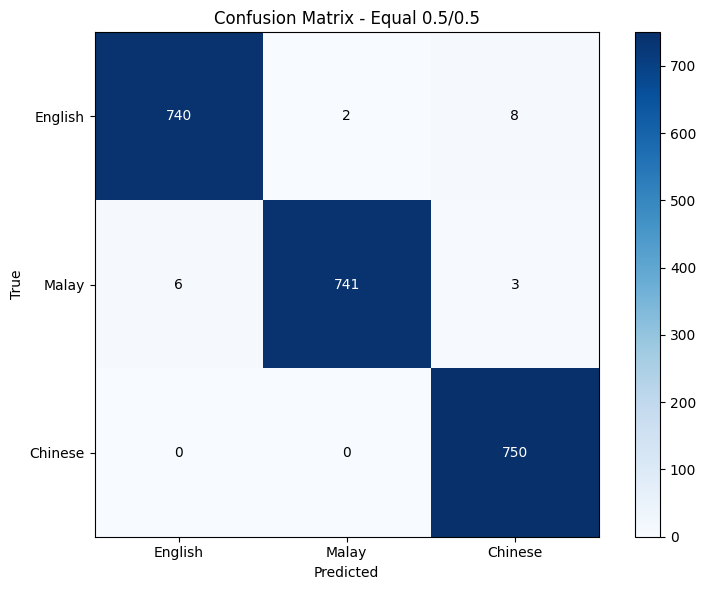

Saved: cnn_fasttext_fusion_results.json


In [35]:
# Detailed report and confusion matrix for best fusion
print('Classification report (best):')
print(classification_report(true_labels, best_preds, target_names=LANGUAGE_NAMES, digits=4, zero_division=0))

cm = confusion_matrix(true_labels, best_preds)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')
ax.figure.colorbar(im, ax=ax)
ax.set_xticks(np.arange(len(LANGUAGE_NAMES)))
ax.set_yticks(np.arange(len(LANGUAGE_NAMES)))
ax.set_xticklabels(LANGUAGE_NAMES)
ax.set_yticklabels(LANGUAGE_NAMES)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix - {best_method}')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='white' if cm[i, j] > cm.max()/2 else 'black')
plt.tight_layout()
plt.show()

# Export results
export = {
    'best_method': best_method,
    'results': results,
    'confusion_matrix': cm.tolist(),
    'test_size': int(true_labels.shape[0])
}
with open('cnn_fasttext_fusion_results.json', 'w') as f:
    json.dump(export, f, indent=2)
print('Saved: cnn_fasttext_fusion_results.json')

## Notes
- Audio model: pretrained mel-spectrogram CNN loaded from best_cnn_fixed_model.pth (3-class).
- Text model: FastText classifier loaded from fasttext_best_model.bin.
- Data: 60% active split, noisy OCR labels (labels_noisy.csv) with fallback to clean labels.
- Fusion: equal, accuracy-weighted (0.6/0.4 favoring audio), and confidence-adaptive; best method selected by overall accuracy.
- Outputs: classification report, confusion matrix, and saved metrics (cnn_fasttext_fusion_results.json).